# Tutorial #2

Import libraries

In [38]:
import os
from image_common_utils import show_image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

set_random_seed(seed_value): Keras uses its source of randomness regardless Theano or TensorFlow.

In addition, TensorFlow has its own random number generator that must also be seeded by calling the set_random_seed() function immediately after the NumPy random number generator.

In [39]:
seed_value = 123; np.random.seed(seed_value)

Import image_common_utils file

In [40]:
exec(open(os.path.abspath('image_common_utils.py')).read())

### Basic image read/write using OpenCv

In [41]:
color_image = cv2.imread('./image_data/balloon.jpg',1)
cv2.namedWindow('image', cv2.WINDOW_NORMAL) # Default: cv2.WINDOW_AUTOSIZE
cv2.imshow('image',color_image)

#Delay in milliseconds. 0 is the special value that means "forever".
k = cv2.waitKey(0) & 0xFF # 0xFF require for 64-bit machines
if k == 27:         # wait for ESC key to exit
    cv2.destroyAllWindows()
elif k == ord('s'): # wait for unicode of 's' key to save and exit
    cv2.imwrite('./image_output/balloon.jpg',color_image)
    cv2.destroyAllWindows()
else:
    cv2.destroyAllWindows()

print('%s%s' %("Existed with unicode: ", str(k)))

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to tar

Existed with unicode: 27


Plot using matplotlib

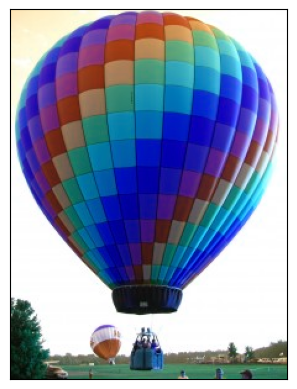

In [42]:
plt.imshow(color_image) #, cmap = 'gray', interpolation = 'bicubic'
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

Color image loaded by OpenCV is in BGR mode. But Matplotlib displays in RGB mode

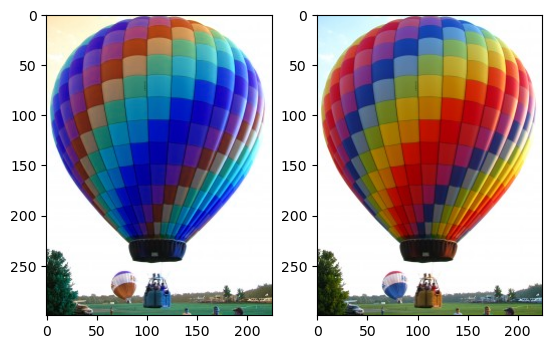

In [43]:
color_image_rgb = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

show_image([color_image, color_image_rgb], row_plot = 1)

### Read/display/save video

In [44]:
# Capture from device index or the name of a video file
capture_video = cv2.VideoCapture(0)

# Define the codec and create VideoWriter object. http://www.fourcc.org/codecs.php
fourcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.VideoWriter('./image_output/video.avi',fourcc,
                      20, # frame per sec
                      (640,480)) # size of video
#Example: frame width and height by capture_video.get(3) and capture_video.get(4). It gives me 640x480 by default.
#To modify it to 320x240. Just use ret = capture_video.set(3,320) and ret = capture_video.set(4,240)

while(capture_video.isOpened()):
    # ret indicates whether or not the frame was captured successfully. If
    # correct, then it's stored in the variable frame.
    ret, frame = capture_video.read()
    #frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if ret==True:
        #frame = cv2.flip(frame,0) # To flip horizontally

        # write the frame
        out.write(frame)

        cv2.imshow('frame',frame)
        k = cv2.waitKey(1) & 0xFF
        if k == 113 or k == 27: # ord('q') -> 113, Esc -> 27
            break
    else:
        break

# Release everything if job is finished
capture_video.release()
out.release()
cv2.destroyAllWindows()

[ WARN:0@373.571] global cap.cpp:643 open VIDEOIO(CV_IMAGES): raised OpenCV exception:

OpenCV(4.10.0) /io/opencv/modules/videoio/src/cap_images.cpp:430: error: (-215:Assertion failed) !filename_pattern.empty() in function 'open'


QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current th

Draw different geometric shapes

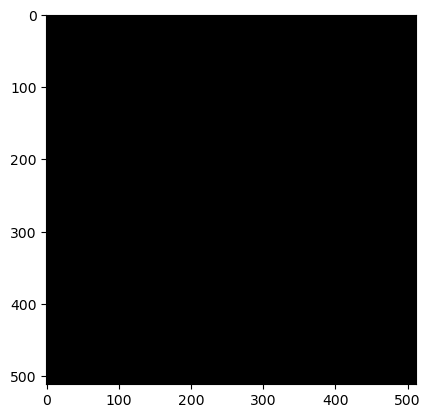

In [45]:
#Create a black image or load any image on which drawing need to be done
img_geo = np.zeros((512,512,3), np.uint8)
plt.imshow(img_geo) 

In [46]:
#Line: Draw a blue line with thickness of 6 px
img_geo = cv2.line(img_geo,(0,0),(511,511),(255,0,0),6)

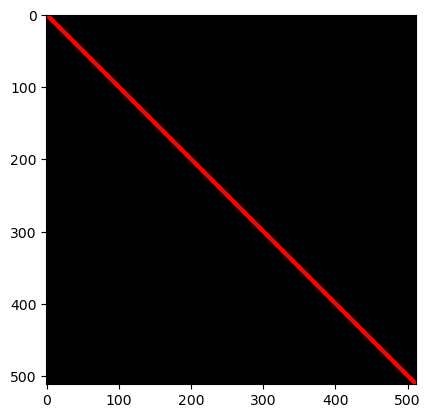

In [47]:
plt.imshow(img_geo) 

In [48]:
#Rectangle (top-left corner and bottom-right corner)
img_geo = cv2.rectangle(img_geo,(384,0),(510,128),(0,255,0),3)

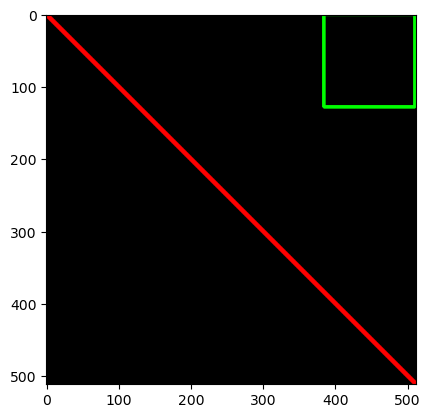

In [49]:
plt.imshow(img_geo)

In [50]:
img_geo = cv2.circle(img_geo,(447,63), 63, (0,0,255), -1)

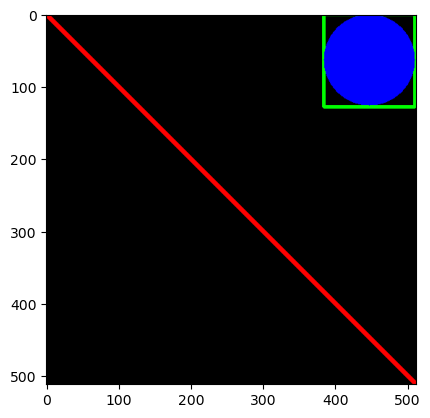

In [51]:
plt.imshow(img_geo)

In [52]:
img_geo = cv2.ellipse(img_geo,(256,256),(100,50),0,0,360,255,-1)

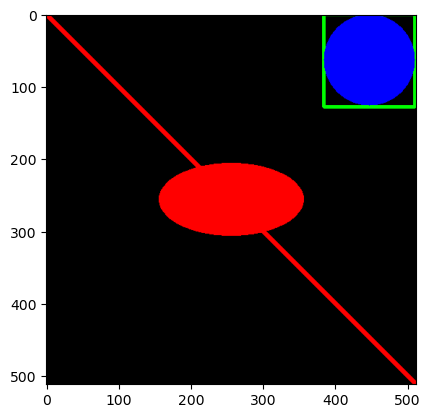

In [53]:
plt.imshow(img_geo)

In [54]:
#Polygon: coordinates of vertices in shape ROWSx1x2 where ROWS are number of vertices
pts = np.array([[10,5],[20,30],[70,20],[50,10]], np.int32)
pts = pts.reshape((-1,1,2))
img_geo = cv2.polylines(img_geo,[pts],
                        True, # If False - get a polylines joining all the points, not a closed shape.
                        (0,255,255))

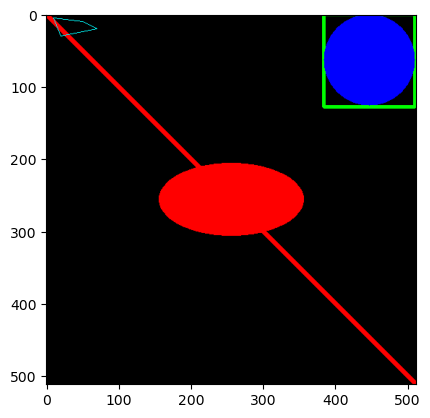

In [55]:
plt.imshow(img_geo)

In [56]:
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img_geo,'Hi OpenCV',(10,500), font, 4,(255,255,255),2,cv2.LINE_AA)

array([[[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]]

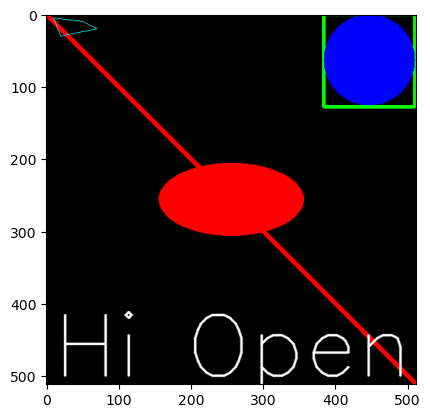

In [57]:
plt.imshow(img_geo)

Get the points where mouse is clicked

In [58]:
events = [i for i in dir(cv2) if 'EVENT' in i]
print(events)

# Create a black image, a window and bind the function to window
my_image = cv2.imread("./image_data/elephant.png", cv2.IMREAD_UNCHANGED)
#my_image = np.zeros((512,512,3), np.uint8)
cv2.namedWindow('my_image')
font = cv2.FONT_HERSHEY_SIMPLEX

# mouse callback function
def event_callback(event,x,y,flags,param):
    if event == cv2.EVENT_LBUTTONDOWN: # get list of events as explained above
        print('%s%s%s' %(str(x),', ', str(y)))
        cv2.putText(my_image,str(x) + ', ' + str(y),(x,y), font, 1,(255,255,255),2,cv2.LINE_AA)

    return

#Bind the function to window
cv2.setMouseCallback('my_image', event_callback)

while(True):
    cv2.imshow('my_image',my_image)
    if cv2.waitKey(10) & 0xFF == 27:
        break

cv2.destroyAllWindows()

['EVENT_FLAG_ALTKEY', 'EVENT_FLAG_CTRLKEY', 'EVENT_FLAG_LBUTTON', 'EVENT_FLAG_MBUTTON', 'EVENT_FLAG_RBUTTON', 'EVENT_FLAG_SHIFTKEY', 'EVENT_LBUTTONDBLCLK', 'EVENT_LBUTTONDOWN', 'EVENT_LBUTTONUP', 'EVENT_MBUTTONDBLCLK', 'EVENT_MBUTTONDOWN', 'EVENT_MBUTTONUP', 'EVENT_MOUSEHWHEEL', 'EVENT_MOUSEMOVE', 'EVENT_MOUSEWHEEL', 'EVENT_RBUTTONDBLCLK', 'EVENT_RBUTTONDOWN', 'EVENT_RBUTTONUP']


QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to target thread (0x56ba5be74570)

QObject::moveToThread: Current thread (0x56ba5be74570) is not the object's thread (0x56ba5c5a39a0).
Cannot move to tar

109, 168
165, 118
276, 92
309, 111
275, 177
167, 214


Click at two different points and draw rectangle

In [59]:
#%% Write on each frame of Video
capture_video = cv2.VideoCapture('./image_data/horse.mp4')
sz = (int(capture_video.get(cv2.CAP_PROP_FRAME_WIDTH)), int(capture_video.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print('WxH is: ',sz)

# Define the codec and create VideoWriter object. http://www.fourcc.org/codecs.php
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # for avi - DIVX, mp4 - mp4v
out = cv2.VideoWriter('./image_output/horse_text.mp4',fourcc, int(capture_video.get(cv2.CAP_PROP_FPS)), sz, True)

count = 0
(label_width, label_height), baseline = cv2.getTextSize(str(count), cv2.FONT_HERSHEY_PLAIN, 3, 2)
print('lw, lh is ', label_width, label_height)

while(capture_video.isOpened()):
    ret, frame = capture_video.read()
    #frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if ret==True:
        # write the frame
        cv2.putText(frame, str(count), (sz[0]-100, sz[1]-100), cv2.FONT_HERSHEY_PLAIN, 3, (0,0,0), 3, cv2.LINE_AA)
        out.write(frame)

    else:
        break
    count = count + 1

# Release everything if job is finished
capture_video.release()
out.release()
cv2.destroyAllWindows()

WxH is:  (490, 360)
lw, lh is  32 28


Playing with color. It was also discusssed with skimage

In [60]:
# Let us read one image
my_image_color = cv2.imread('./image_data/elephant.png')

In [61]:
# Convert BGR to HSV
my_image_color_hsv = cv2.cvtColor(my_image_color,cv2.COLOR_BGR2HSV)

In [62]:
lower_range = np.array([30,0,0]); upper_range = np.array([90,255,255])

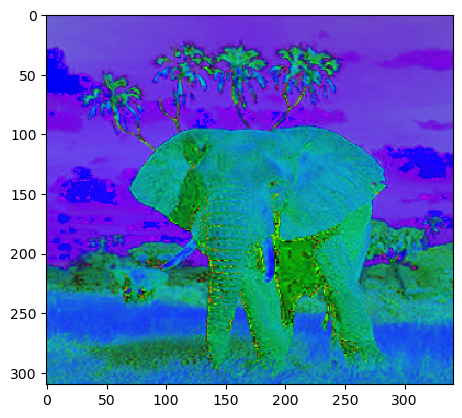

In [63]:
# Threshold the HSV image to get only blue colors
mask = cv2.inRange(my_image_color_hsv, lower_range, upper_range)
plt.imshow(my_image_color_hsv)

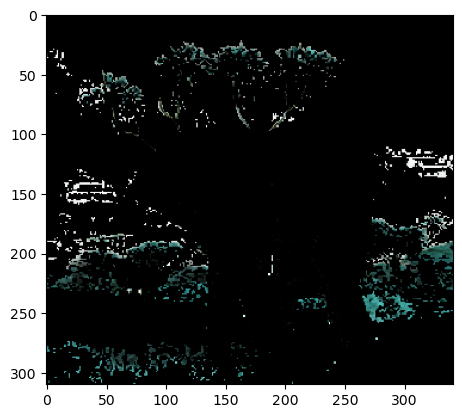

In [64]:
my_image_color_hsv_green = cv2.bitwise_and(my_image_color,my_image_color,mask = mask)
plt.imshow(my_image_color_hsv_green)

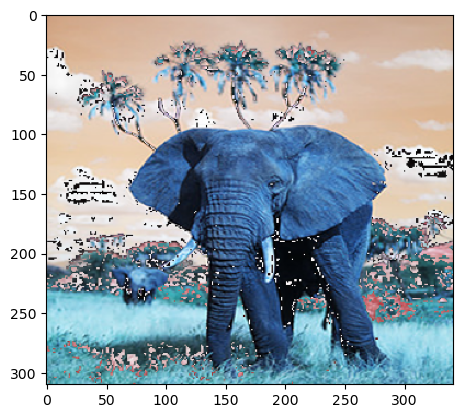

In [65]:
my_image_color_hsv_NON_green = cv2.bitwise_not(my_image_color,my_image_color,mask = mask)
plt.imshow(my_image_color_hsv_NON_green)

Various transformations

In [66]:
# Let us read one image
my_image_color = cv2.imread('./image_data/elephant.png')

In [67]:
# get w & h
h, w = my_image_color.shape[:2]

In [68]:
# Define source and destination points
trans_src_points = np.float32([[0,0], [w-1,0], [0,h-1]])
trans_dst_points = np.float32([[int(w/2),0], [w-1,0], [0,h-1]])

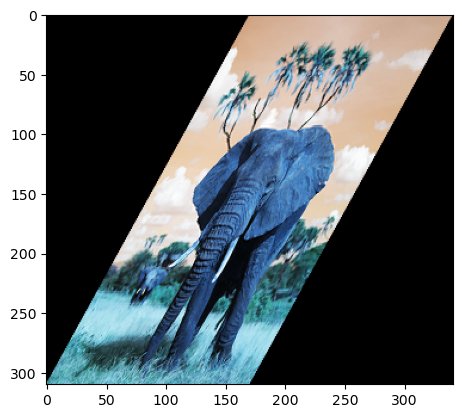

In [69]:
# Do the transformations
affine_matrix = cv2.getAffineTransform(trans_src_points, trans_dst_points)
my_image_affine = cv2.warpAffine(my_image_color, affine_matrix, (w,h))
plt.imshow(my_image_affine)

**-------- END OF 2.1 Image_opencv_basics.py --------**